# Part 1 → RNN


## Sentiment Analysis with RNN on Amazon Fine Food Reviews

## Dataset
- **Amazon Fine Food Reviews**  
- [Download from Kaggle](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews)  
- Dataset contains **500,000+ reviews** with ratings (1–5 stars).

## Objective
- Build a **Recurrent Neural Network (RNN)** model to predict review sentiment:
  - **Multi-class** → Ratings from 1 to 5 stars  


## Steps

### 1. Data Preprocessing
- Load the CSV file → focus on **`Text`** + **`Score`** columns.
- Clean text: lowercase, remove punctuation, (optional: remove stopwords).
- Tokenize reviews (convert words to numbers).
- Pad sequences to a fixed length.
- Convert labels:
  - Multi-class (1–5 → one-hot encoded).

### 2. Build RNN Model
- Use **Embedding Layer** to convert tokens into vectors.
- Add **SimpleRNN layer** (e.g., 32 or 64 units).
- Add **Dense output layer**:
  - Activation = `softmax` (for multi-class classification).

### 3. Training
- Compile with:
  - Optimizer → `adam`
  - Loss → `categorical_crossentropy` (multi-class)
  - Metric → `accuracy`
- Train for **5–10 epochs**.
- Use a **validation split** (e.g., 20%).

### 4. Evaluation
- Evaluate model on test set.
- Show:
  - **Accuracy score**
  - **Confusion matrix**
- Print a few **example predictions**:
  - Input review
  - True label
  - Predicted sentiment

### 5. User Input Prediction
- After training, let the user type **any review sentence**.  
- Preprocess it the same way (tokenize + pad).  
- Pass it to the trained RNN model.  
- Print the predicted sentiment (Rating 1–5).  

## Hints
- Start with a **small subset** of the dataset (e.g., 20k reviews) to save training time.
- Watch for **overfitting** (training accuracy much higher than validation).

## Data Preprocessing

In [51]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import re
!pip install nltk

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Load a sample of the dataset
df = pd.read_csv('/kaggle/input/amazon-fine-food-reviews/Reviews.csv')

df = df[['Text', 'Score']]
df.dropna(inplace=True)
df=df.drop_duplicates()

# --- Text Cleaning ---
def clean_text(text):
    stop_words = set(stopwords.words('english'))
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    text = " ".join(filtered_words)
    
    return text

df['Cleaned_Text'] = df['Text'].apply(clean_text)

# --- Prepare Labels ---
# Convert scores (1-5) to an array index (0-4) for multi-class classification
labels = df['Score'].values - 1

# --- Tokenization and Padding ---
MAX_VOCAB_SIZE = 10000  # Maximum number of words to keep
MAX_SEQUENCE_LENGTH = 150 # Maximum length of a review to consider

# Create a tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['Cleaned_Text'])

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['Cleaned_Text'])

# Pad sequences to ensure they all have the same length
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# --- One-Hot Encode Labels ---
one_hot_labels = tf.keras.utils.to_categorical(labels, num_classes=5)


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [52]:
df.head()

,Text,Score,Cleaned_Text
0,I have bought several of the Vitality canned d...,5,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,1,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,4,confection around centuries light pillowy citr...
3,If you are looking for the secret ingredient i...,2,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,5,great taffy great price wide assortment yummy ...


In [53]:
df.duplicated().sum()

0

In [54]:
# --- Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    one_hot_labels,
    test_size=0.2, # 20% for testing
    random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training data shape: (314940, 150)
Testing data shape: (78735, 150)
Training labels shape: (314940, 5)
Testing labels shape: (78735, 5)


In [55]:
X_train

array([[1438,   46,  426, ...,    0,    0,    0],
       [   5,  472, 2234, ...,    0,    0,    0],
       [ 215,  531, 4093, ...,    0,    0,    0],
       ...,
       [  20,  582, 8065, ...,    0,    0,    0],
       [  59,   82,  149, ...,    0,    0,    0],
       [  46,  159, 2316, ...,    0,    0,    0]], dtype=int32)

In [56]:
y_train

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.]])

## Build RNN model

In [57]:
EMBEDDING_DIM = 64 # Dimension of the word vectors

model = Sequential([
    # 1. Embedding Layer
    Embedding(input_dim=MAX_VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQUENCE_LENGTH),

    # 2. SimpleRNN Layer
    SimpleRNN(units=64, activation='relu'),

    # 3. Dense Output Layer
    Dense(units=5, activation='softmax') # 5 units for 5 sentiment classes (1-5 stars)
])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [58]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
EPOCHS = 10
BATCH_SIZE = 128

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.6344 - loss: 1.1502 - val_accuracy: 0.6353 - val_loss: 1.1391
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.6377 - loss: 1.1301 - val_accuracy: 0.6342 - val_loss: 1.1425
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.6422 - loss: 1.1210 - val_accuracy: 0.6343 - val_loss: 1.1472
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.6457 - loss: 1.1205 - val_accuracy: 0.6317 - val_loss: 1.1603
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.6477 - loss: 1.1076 - val_accuracy: 0.6316 - val_loss: 1.1685
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.6495 - loss: 1.1029 - val_accuracy: 0.6318 - val_loss: 1.1765
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.6490 - loss: 1.1032 - val_accuracy: 0.6323 - val_loss: 1.1794
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.6486 -

## Evaluation

In [59]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {accuracy*100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")

2461/2461 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6353 - loss: 1.1738

✅ Test Accuracy: 63.50%
✅ Test Loss: 1.1775


2461/2461 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step


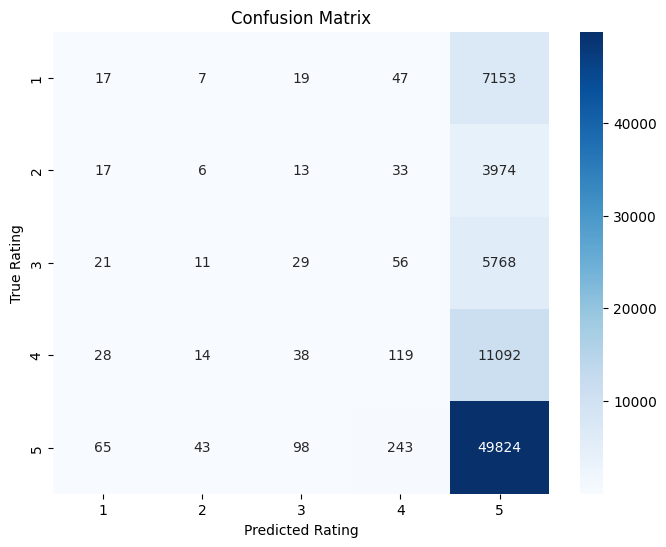

In [60]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions (probabilities)
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels (0-4)
y_pred = np.argmax(y_pred_probs, axis=1)

# We also need to convert the one-hot encoded true labels back to single numbers
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 6), yticklabels=range(1, 6))
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.title('Confusion Matrix')
plt.show()

## User input Prediction

In [61]:
def predict_sentiment(review_text):
    """
    Takes a raw review text and predicts the sentiment rating (1-5).
    """
    # 1. Clean the text using the same function as before.
    cleaned_text = clean_text(review_text)

    # 2. Tokenize the text using the trained tokenizer.
    # Note: texts_to_sequences expects a list of strings.
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # 3. Pad the sequence to the same length as the training data.
    padded_sequence = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

    # 4. Make a prediction. The output is a probability distribution.
    prediction_probs = model.predict(padded_sequence)
    
    # 5. Find the class with the highest probability and convert it back to a 1-5 rating.
    predicted_class = np.argmax(prediction_probs, axis=1)[0]
    predicted_rating = predicted_class + 1
    
    return predicted_rating

In [62]:
# --- Example 1: A very positive review ---
my_review_1 = "This is by far the best coffee I have ever had. The aroma is incredible and the taste is rich and smooth. Will definitely be buying this again!"
predicted_rating_1 = predict_sentiment(my_review_1)

print(f"Review: '{my_review_1}'")
print(f" Predicted Sentiment (Rating): {predicted_rating_1} ⭐\n")


# --- Example 2: A very negative review ---
my_review_2 = "The product arrived with a broken seal and the chips inside were stale and tasted awful. A complete waste of money. I am very disappointed."
predicted_rating_2 = predict_sentiment(my_review_2)

print(f"Review: '{my_review_2}'")
print(f" Predicted Sentiment (Rating): {predicted_rating_2} ⭐\n")


# --- Example 3: A more neutral or mixed review ---
my_review_3 = "It was an okay product. Not the best I've had, but not the worst either. The price is reasonable for what you get."
predicted_rating_3 = predict_sentiment(my_review_3)

print(f"Review: '{my_review_3}'")
print(f" Predicted Sentiment (Rating): {predicted_rating_3} ⭐\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Review: 'This is by far the best coffee I have ever had. The aroma is incredible and the taste is rich and smooth. Will definitely be buying this again!'
 Predicted Sentiment (Rating): 5 ⭐

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Review: 'The product arrived with a broken seal and the chips inside were stale and tasted awful. A complete waste of money. I am very disappointed.'
 Predicted Sentiment (Rating): 5 ⭐

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Review: 'It was an okay product. Not the best I've had, but not the worst either. The price is reasonable for what you get.'
 Predicted Sentiment (Rating): 5 ⭐



### It predicts 5 on all. That's an imbalance

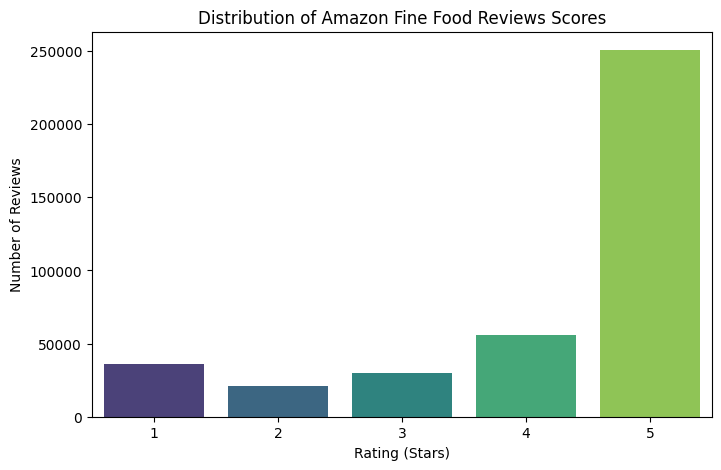

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of scores
plt.figure(figsize=(8, 5))
sns.countplot(x='Score', data=df, palette='viridis')
plt.title('Distribution of Amazon Fine Food Reviews Scores')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Reviews')
plt.show()

# Part 2 – LSTM
1. **Build LSTM Model**
   - Keep preprocessing exactly the same.
   - Replace `SimpleRNN` with `LSTM` (e.g., 64–128 units).
   - Dense output (sigmoid or softmax).

2. **Training**
   - Same setup (adam, crossentropy, accuracy).
   - Train for 5–10 epochs.

3. **Evaluation**
   - Compare accuracy with RNN model.
   - Show confusion matrix.
   - Example predictions.

4. **User Input Prediction. **
   - Take a sentence from user.
   - Preprocess (tokenize + pad).
   - Predict sentiment using the LSTM model.

## Hints
- Use a **smaller subset** (e.g., 20k reviews) for quick experiments.
- Compare:
  - Training speed (RNN faster, LSTM slower).
  - Accuracy on long reviews.

## Deliverables
1. Notebook with:
   - RNN implementation
   - LSTM implementation
2. Final accuracy + confusion matrix for both models.
3. Comparison table (RNN vs LSTM).
4. Demo that accepts **any user sentence** and predicts sentiment with both models.

## Build LSTM model

In [64]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

EMBEDDING_DIM = 64
LSTM_UNITS = 64

model_lstm = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQUENCE_LENGTH),

    Bidirectional(LSTM(units=LSTM_UNITS)), 


    Dense(units=5, activation='softmax')
])

model_lstm.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [70]:
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Compile the Model ---
model_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 2. Prepare for Training ---
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

EPOCHS = 10
BATCH_SIZE = 32

# --- 3. Train the Model ---
print("🚀 Starting LSTM Model Training (without class weights)...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
print("✅ LSTM Model Training Complete.")

🚀 Starting LSTM Model Training (without class weights)...
Epoch 1/10
7874/7874 ━━━━━━━━━━━━━━━━━━━━ 108s 13ms/step - accuracy: 0.7494 - loss: 0.6702 - val_accuracy: 0.7299 - val_loss: 0.7388
Epoch 2/10
7874/7874 ━━━━━━━━━━━━━━━━━━━━ 105s 13ms/step - accuracy: 0.7662 - loss: 0.6248 - val_accuracy: 0.7277 - val_loss: 0.7366
Epoch 3/10
7874/7874 ━━━━━━━━━━━━━━━━━━━━ 105s 13ms/step - accuracy: 0.7862 - loss: 0.5747 - val_accuracy: 0.7223 - val_loss: 0.7706
Epoch 4/10
7874/7874 ━━━━━━━━━━━━━━━━━━━━ 105s 13ms/step - accuracy: 0.8033 - loss: 0.5257 - val_accuracy: 0.7204 - val_loss: 0.7911
Epoch 5/10
7874/7874 ━━━━━━━━━━━━━━━━━━━━ 105s 13ms/step - accuracy: 0.8225 - loss: 0.4763 - val_accuracy: 0.7096 - val_loss: 0.8573
✅ LSTM Model Training Complete.


## Evaluation

In [71]:
# Evaluate the LSTM model on the test set
loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test, y_test)
print(f"✅ LSTM Model Test Accuracy: {accuracy_lstm*100:.2f}%")

# --- Comparison ---
accuracy_rnn = 0.648 

print("\n--- Performance Comparison ---")
print(f"SimpleRNN Accuracy: {accuracy_rnn*100:.2f}%")
print(f"LSTM Accuracy:      {accuracy_lstm*100:.2f}%")

improvement = accuracy_lstm - accuracy_rnn
print(f"\nImprovement: +{improvement*100:.2f}%")

2461/2461 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7298 - loss: 0.7397
✅ LSTM Model Test Accuracy: 73.09%

--- Performance Comparison ---
SimpleRNN Accuracy: 64.80%
LSTM Accuracy:      73.09%

Improvement: +8.29%


## User input prediction

In [72]:
import numpy as np

def predict_sentiment_lstm(review_text):
    """
    Takes a raw review string and predicts the sentiment rating (1-5)
    using the trained LSTM model.
    """
    # 1. Clean the text.
    cleaned_text = clean_text(review_text)

    # 2. Tokenize the text using the same tokenizer from training.
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # 3. Pad the sequence to the fixed length the model expects.
    padded_sequence = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

    # 4. Use the trained LSTM model to make a prediction.
    prediction_probs = model_lstm.predict(padded_sequence)
    
    # 5. Get the index of the highest probability and convert it to a 1-5 star rating.
    predicted_class = np.argmax(prediction_probs, axis=1)[0]
    predicted_rating = predicted_class + 1
    
    return predicted_rating

In [73]:
# --- Example 1: The Hype is Real (Positive) ---
positive_review = "Ngl, I was sleeping on this at first, but this thing is straight fire. Blew my mind, honestly. 10/10 would cop again."
rating = predict_sentiment_lstm(positive_review)
print(f"The review: '{positive_review}'")
print(f" > The bot's take is: {rating} ⭐\n")

# --- Example 2: Total Bust (Negative) ---
negative_review = "Big L buying this. The quality was straight trash and it crapped out on me after like, two uses. Hard pass, save your money."
rating = predict_sentiment_lstm(negative_review)
print(f"The review: '{negative_review}'")
print(f" > The bot's take is: {rating} ⭐\n")

# --- Example 3: Kinda Mid (Neutral) ---
neutral_review = "Shipping was quick, so props for that. But the product itself is kinda mid, ngl. It works, but it's not blowing my mind or anything."
rating = predict_sentiment_lstm(neutral_review)
print(f"The review: '{neutral_review}'")
print(f" > The bot's take is: {rating} ⭐\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
The review: 'Ngl, I was sleeping on this at first, but this thing is straight fire. Blew my mind, honestly. 10/10 would cop again.'
 > The bot's take is: 5 ⭐

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
The review: 'Big L buying this. The quality was straight trash and it crapped out on me after like, two uses. Hard pass, save your money.'
 > The bot's take is: 1 ⭐

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
The review: 'Shipping was quick, so props for that. But the product itself is kinda mid, ngl. It works, but it's not blowing my mind or anything.'
 > The bot's take is: 4 ⭐

